<a href="https://colab.research.google.com/github/CarlosBaztan/TFM-Imperial-Brands-Group/blob/main/ClusteringTFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###### Clustering de outlets - TFM Altadis
## Objetivo 4: Clusterización de datos
Este notebook segmenta los 2.957 outlets con tamaño conocido (Tam_m2 != 'N.D.') en grupos según su perfil de negocio, combinando
variables descriptivas (tamaño, renta provincial) con variables de comportamiento de venta (volumen, rotura de stock, diversidad de catálogo).

Fichero de entrada esperado: TablaClustering.csv (exportado desde SQL Server,
separador ;, decimales con coma, sin cabecera).

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)

#####Celda 3 (código — carga y limpieza del CSV):

In [4]:
cols = ['Affiliated_Code','Provincia','Location','Tam_m2_Numerico',
        'Renta_Media_Provincial','Ventas_Totales','Tasa_Rotura','Num_Productos_Distintos']

df = pd.read_csv('TablaClustering.csv', sep=';', decimal=',',
                  header=None, names=cols, encoding='utf-8-sig')

# Tam_m2_Numerico usa punto decimal, no coma: se corrige por separado
df['Tam_m2_Numerico'] = df['Tam_m2_Numerico'].astype(float)

print(df.shape)
print(df.dtypes)
df.head()

(2957, 8)
Affiliated_Code             object
Provincia                   object
Location                    object
Tam_m2_Numerico            float64
Renta_Media_Provincial       int64
Ventas_Totales               int64
Tasa_Rotura                float64
Num_Productos_Distintos      int64
dtype: object


,Affiliated_Code,Provincia,Location,Tam_m2_Numerico,Renta_Media_Provincial,Ventas_Totales,Tasa_Rotura,Num_Productos_Distintos
0,Wl31AAD,Valladolid,ANY,7.5,11682,658,0.000000,15
1,WlH0AAL,A Coruña,ESCAPE,15.0,11024,742,0.000000,17
2,WlPyAAL,Barcelona,CITY,3.5,12853,751,0.000000,20
3,WqbCAAT,Jaén,ANY,15.0,8318,441,0.003559,15
4,WqflAAD,Madrid,BORDER,1.0,13779,1416,0.001730,22


#####Celda 4 (código — verificación de calidad):

In [5]:
# Verificación de calidad: no debe haber nulos
print(df.isnull().sum())
print()
print(df.describe().round(2))

Affiliated_Code            0
Provincia                  0
Location                   0
Tam_m2_Numerico            0
Renta_Media_Provincial     0
Ventas_Totales             0
Tasa_Rotura                0
Num_Productos_Distintos    0
dtype: int64

       Tam_m2_Numerico  Renta_Media_Provincial  Ventas_Totales  Tasa_Rotura  Num_Productos_Distintos
count          2957.00                 2957.00         2957.00      2957.00                  2957.00
mean             10.77                10859.23          664.12         0.00                    15.75
std               8.30                 1984.23          535.74         0.00                     4.96
min               1.00                 8029.00            1.00         0.00                     1.00
25%               3.50                 8908.00          284.00         0.00                    13.00
50%               7.50                10667.00          528.00         0.00                    16.00
75%              15.00                12853.00 

####### 2. Selección de variables

Variables incluidas en el clustering: Tam_m2_Numerico, Renta_Media_Provincial,
Ventas_Totales, Tasa_Rotura, Num_Productos_Distintos.

Se excluyen Provincia (alta cardinalidad, parcialmente redundante con la renta)
y Location (se reserva como variable de caracterización posterior, no de entrada
al algoritmo, para poder usarla luego como lectura cualitativa de cada cluster).

Las variables se estandarizan (media 0, desviación 1) antes de aplicar k-means,
ya que están en escalas muy distintas (la renta está en miles de euros, la tasa
de rotura en decimales entre 0 y 1).

In [ ]:
#Celda 6 (código — estandarización):

In [6]:
features = ['Tam_m2_Numerico','Renta_Media_Provincial','Ventas_Totales',
            'Tasa_Rotura','Num_Productos_Distintos']

X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

####### 3. Elección del número de clusters

Se evalúan los valores de k entre 2 y 8 mediante el método del codo (inercia)
y el coeficiente de silueta (silhouette score), para justificar la elección
de k de forma objetiva en lugar de arbitraria.

In [7]:
#Celda 8 (código — cálculo de inercia y silhouette):
inertias = []
silhouettes = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

resultados_k = pd.DataFrame({'k': list(K_range), 'Inercia': inertias, 'Silhouette': silhouettes})
print(resultados_k)

   k       Inercia  Silhouette
0  2  11692.077806    0.219152
1  3   9977.040830    0.223310
2  4   8401.588527    0.230005
3  5   7112.504832    0.232860
4  6   6100.170123    0.245683
5  7   5538.540535    0.254076
6  8   5030.557729    0.242049


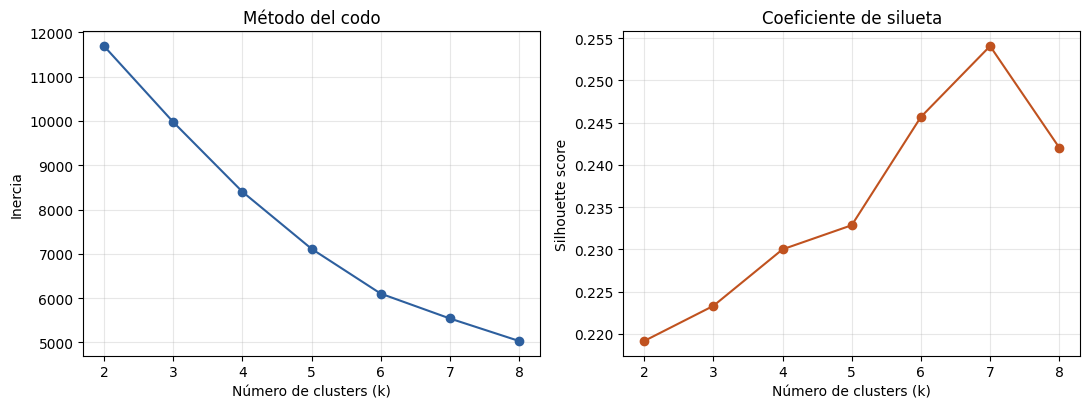

In [8]:
#Celda 9 (código — gráficos de codo y silhouette):
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].plot(K_range, inertias, marker='o', color='#2D5F9E')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del codo')
axes[0].grid(alpha=0.3)

axes[1].plot(K_range, silhouettes, marker='o', color='#C0521F')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Coeficiente de silueta')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Clustering_Eleccion_K.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


#####**Decisión:**
Se elige **k=5**. El silhouette score máximo se alcanza en k=7 (0,254), pero la diferencia frente a k=5 (0,233) es reducida, y un número menor de clusters
resulta más manejable para la interpretación de negocio y la presentación de resultados
en el TFM, sin pérdida sustancial de calidad del agrupamiento.

####### 4. Primera ejecución con k=5: detección de un cluster degenerado

Una primera ejecución de k-means con k=5 sobre el conjunto completo (2.957 outlets)
produjo un cluster de únicamente 5 observaciones, lo que indica un grupo de outliers
extremos más que un segmento de negocio real.

In [9]:
#Celda 12 (código — primera ejecución con k=5):
km_inicial = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_Inicial'] = km_inicial.fit_predict(X_scaled)

print(df['Cluster_Inicial'].value_counts().sort_index())

Cluster_Inicial
0     761
1     729
2       5
3    1095
4     367
Name: count, dtype: int64


In [10]:
#Celda 13 (código — inspección del cluster degenerado):
# Inspección del cluster minoritario
cluster_pequeno = df['Cluster_Inicial'].value_counts().idxmin()
outliers = df[df['Cluster_Inicial'] == cluster_pequeno]

print(f"Outlets en el cluster degenerado: {len(outliers)}")
print(outliers[features + ['Affiliated_Code','Provincia']])
print()
print("Media general de Tasa_Rotura:", df['Tasa_Rotura'].mean())
print("Tasa_Rotura de estos outlets:", outliers['Tasa_Rotura'].values)

Outlets en el cluster degenerado: 5
      Tam_m2_Numerico  Renta_Media_Provincial  Ventas_Totales  Tasa_Rotura  Num_Productos_Distintos Affiliated_Code  \
120              15.0                    9009              88     0.069767                        3         Wqi1AAD   
592              26.0                   10153             242     0.054054                        7         Wu68AAD   
645               3.5                    8845              54     0.085714                        5         WU5RAAX   
1711             26.0                    8908             195     0.051613                       16         WkMuAAL   
2850              1.0                    8845             149     0.072727                        7         XCWfAAP   

       Provincia  
120       Cuenca  
592   Pontevedra  
645       Toledo  
1711      Murcia  
2850      Toledo  

Media general de Tasa_Rotura: 0.0009232805254985511
Tasa_Rotura de estos outlets: [0.06976744 0.05405405 0.08571429 0.0516129  0.07272

#####**Hallazgo:**
Estos 5 outlets tienen una tasa de rotura de stock entre 50 y 90 veces
superior a la media de la red (0,05–0,086 frente a 0,0009 de media general).
No constituyen un segmento de negocio por su reducido tamaño muestral, sino un hallazgo
cualitativo independiente: outlets con un problema de suministro extremo y aislado que
merece atención prioritaria, documentado aparte del análisis de clustering principal.

Se excluyen del clustering y se repite el proceso sobre los 2.952 outlets restantes.

In [11]:
#Celda 15 (código — re-clustering sin outliers):
df_sin_outliers = df[df['Cluster_Inicial'] != cluster_pequeno].copy()
print("Outlets tras excluir los outliers extremos de rotura:", len(df_sin_outliers))

X2 = df_sin_outliers[features].values
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# Se reconfirma que k=5 sigue siendo razonable sin los outliers
for k in [4,5,6]:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_test.fit_predict(X2_scaled)
    sil = silhouette_score(X2_scaled, labels)
    print(f"k={k}: silhouette={sil:.4f}, tamaños={np.bincount(labels)}")

Outlets tras excluir los outliers extremos de rotura: 2952
k=4: silhouette=0.2376, tamaños=[1225  960  541  226]
k=5: silhouette=0.2373, tamaños=[715 959 727 193 358]
k=6: silhouette=0.2470, tamaños=[808 740 340 180 569 315]


### 5. Clustering final (k=5, sin outliers de rotura)

In [12]:
#Celda 17 (código — clustering final):
km_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df_sin_outliers['Cluster'] = km_final.fit_predict(X2_scaled)

print(df_sin_outliers['Cluster'].value_counts().sort_index())

Cluster
0    715
1    959
2    727
3    193
4    358
Name: count, dtype: int64


In [13]:
#Celda 18 (código — perfil de cada cluster):
perfil = df_sin_outliers.groupby('Cluster')[features].mean().round(2)
perfil['N_Outlets'] = df_sin_outliers['Cluster'].value_counts().sort_index()
print(perfil)

         Tam_m2_Numerico  Renta_Media_Provincial  Ventas_Totales  Tasa_Rotura  Num_Productos_Distintos  N_Outlets
Cluster                                                                                                          
0                   7.82                13169.09          461.57         0.00                    15.52        715
1                   7.78                 9534.26          383.93         0.00                    12.55        959
2                   9.54                10743.14         1285.79         0.00                    20.56        727
3                   9.00                10560.72          427.53         0.01                    14.01        193
4                  28.03                10215.77          691.61         0.00                    16.06        358


In [14]:
#Celda 19 (código — Location dominante por cluster):
# Caracterización cualitativa: tipo de Location dominante por cluster
for c in sorted(df_sin_outliers['Cluster'].unique()):
    top_loc = df_sin_outliers[df_sin_outliers['Cluster']==c]['Location'].value_counts().head(2)
    print(f"Cluster {c}: {dict(top_loc)}")

Cluster 0: {'ANY': np.int64(211), 'CITY': np.int64(167)}
Cluster 1: {'VILLAGE': np.int64(333), 'ANY': np.int64(278)}
Cluster 2: {'ANY': np.int64(262), 'VILLAGE': np.int64(216)}
Cluster 3: {'VILLAGE': np.int64(58), 'ANY': np.int64(53)}
Cluster 4: {'ANY': np.int64(133), 'VILLAGE': np.int64(117)}


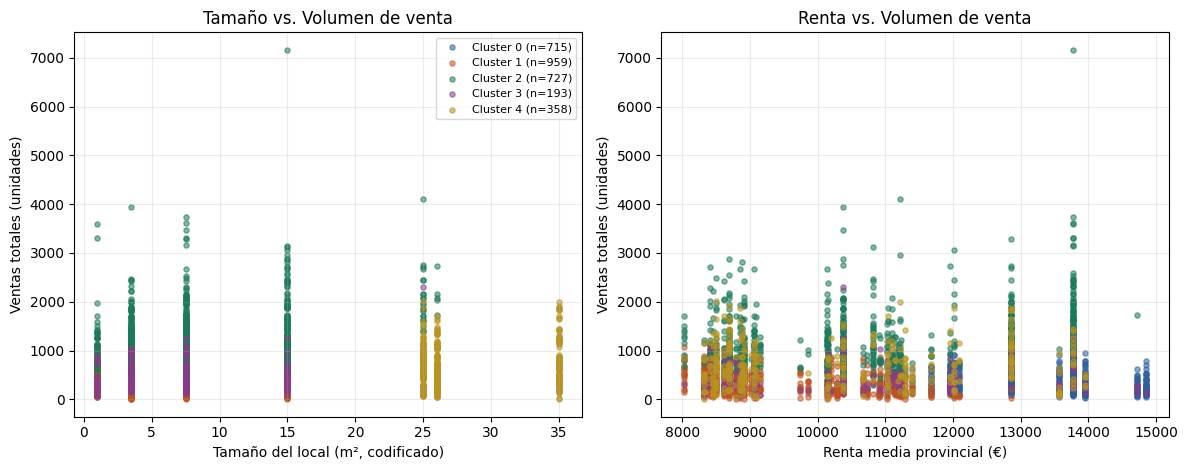

In [15]:
#Última celda de código — el gráfico final de los clusters:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
colors = ['#2D5F9E','#C0521F','#1C7A5C','#8B3A8B','#B8941F']

for c in sorted(df_sin_outliers['Cluster'].unique()):
    sub = df_sin_outliers[df_sin_outliers['Cluster']==c]
    axes[0].scatter(sub['Tam_m2_Numerico'], sub['Ventas_Totales'],
                     s=14, alpha=0.55, color=colors[c], label=f'Cluster {c} (n={len(sub)})')
axes[0].set_xlabel('Tamaño del local (m², codificado)')
axes[0].set_ylabel('Ventas totales (unidades)')
axes[0].set_title('Tamaño vs. Volumen de venta')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.25)

for c in sorted(df_sin_outliers['Cluster'].unique()):
    sub = df_sin_outliers[df_sin_outliers['Cluster']==c]
    axes[1].scatter(sub['Renta_Media_Provincial'], sub['Ventas_Totales'],
                     s=14, alpha=0.55, color=colors[c])
axes[1].set_xlabel('Renta media provincial (€)')
axes[1].set_ylabel('Ventas totales (unidades)')
axes[1].set_title('Renta vs. Volumen de venta')
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.savefig('Clustering_Resultado_5_Grupos.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

In [16]:
# Exportar resultado para uso posterior (Power BI / informe)
df_sin_outliers.to_csv('Outlets_con_Cluster.csv', index=False)
outliers.to_csv('Outlets_Outliers_Rotura.csv', index=False)
print("Ficheros exportados correctamente.")

Ficheros exportados correctamente.


##### 6. Interpretación de negocio

- **Cluster 0** (715 outlets): tamaño pequeño, renta provincial alta, venta media.
- **Cluster 1** (959 outlets, el más numeroso): tamaño pequeño, renta baja, venta baja y catálogo reducido — el segmento de menor rendimiento comercial.
- **Cluster 2** (727 outlets): venta notablemente superior al resto (casi el triple de la media) y mayor diversidad de catálogo — el segmento de mejor desempeño.
- **Cluster 3** (193 outlets): perfil similar al promedio, pero con una tasa de rotura de stock más elevada que el resto de grupos (sin llegar a ser un caso extremo).
- **Cluster 4** (358 outlets): único grupo diferenciado claramente por el tamaño físico del local (28 m² de media frente a 7-9 m² del resto), sin que ese mayor tamaño se traduzca en un volumen de venta proporcionalmente superior.

**Conclusión principal:** el tamaño físico del local no es el factor que mejor explica
las diferencias de rendimiento comercial entre outlets; el comportamiento de venta
(volumen y diversidad de catálogo) separa los grupos con más claridad que las variables
puramente descriptivas (tamaño, renta).
